<a href="https://colab.research.google.com/github/rupammoitra/Deep-Learning-Based-Encoder-Decoder-for-Retinal-Blood-Vessel-Segmentation/blob/main/Blood_vessel_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow-datasets

In [2]:
!pip install scikit-image

In [3]:
from scipy import misc
from PIL import Image
from skimage import exposure
from sklearn import svm

import scipy
from math import sqrt,pi
from numpy import exp
from matplotlib import pyplot as plt
import numpy as np
import glob
import matplotlib.pyplot as pltss
import cv2
from matplotlib import cm
import pandas as pd
from math import pi, sqrt
import pywt

/tmp/ipykernel_3454/2369155777.py:1: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

with zipfile.ZipFile("/content/drive/MyDrive/DRIVE.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/DRIVE")

with zipfile.ZipFile("/content/drive/MyDrive/A. Segmentation (1).zip", 'r') as zip_ref:
    zip_ref.extractall("/content/SEG")

print("Extraction done")

Extraction done


In [6]:
import os
import cv2
import numpy as np

imatrix = []

folders = [
    "/content/DRIVE/DRIVE/test/images",
    "/content/DRIVE/DRIVE/training/images"
]
for folder in folders:
  for root, dirs, files in os.walk(folder):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            img_path = os.path.join(root, file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            green = img[:, :, 1]

            equ = cv2.equalizeHist(green)
            equ = cv2.GaussianBlur(equ, (3,3), 0)

            imatrix.append(equ)

print(len(imatrix))

40


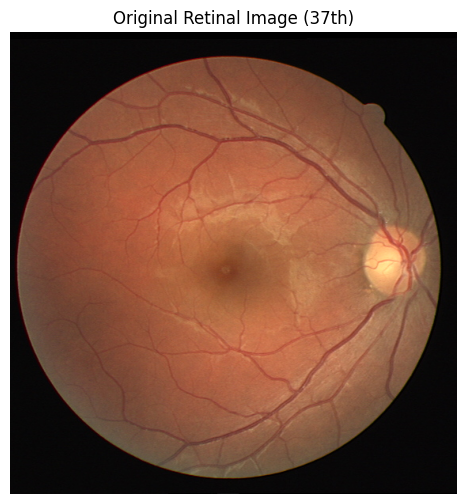

In [7]:
folders = [
    "/content/DRIVE/DRIVE/test/images",
    "/content/DRIVE/DRIVE/training/images"
]

all_images = []

for folder in folders:
    for file in sorted(os.listdir(folder)):
        if file.lower().endswith((".tif", ".tiff")):
            all_images.append(os.path.join(folder, file))

img = cv2.imread(all_images[36])   # 37th image (index starts at 0)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Retinal Image (37th)")
plt.axis("off")
plt.show()

Number of images loaded: 40


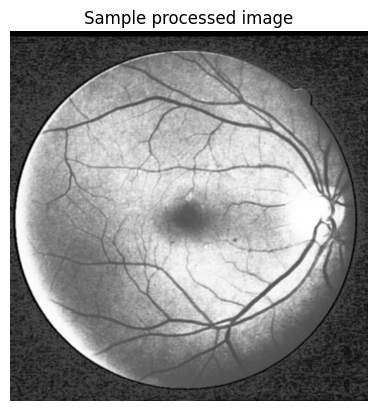

In [8]:
import matplotlib.pyplot as plt

print("Number of images loaded:", len(imatrix))

if len(imatrix) > 0:

    index = 37
    if len(imatrix) <= 5:
        index = 0

    img = imatrix[index]



    plt.imshow(img, cmap='gray')
    plt.title("Sample processed image")
    plt.axis('off')
    plt.show()

else:
    print("No images found in imatrix")

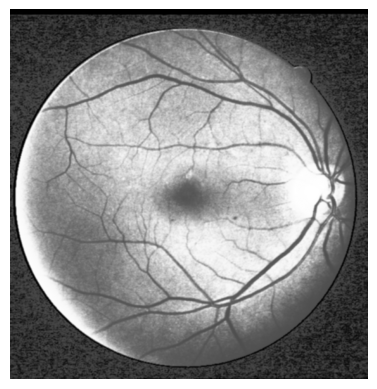

In [9]:
import matplotlib.pyplot as plt

index = 37

if index < len(imatrix):
    plt.imshow(imatrix[index], cmap='gray')
    plt.axis('off')
    plt.show()
else:
    print("Index out of range")

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

imatrix = []

folder = [
    "/content/DRIVE/DRIVE/test/images"
    "/content/DRIVE/DRIVE/Training/images"
]
for folder in folders:
 for root, dirs, files in os.walk(folder):
    for file in sorted(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            img_path = os.path.join(root, file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            green = img[:, :, 1]

            equ = cv2.equalizeHist(green)

            imatrix.append(equ)

print("Images loaded:", len(imatrix))


def createMatchedFilterBank():
    filters = []
    ksize = 31

    for theta in np.arange(0, np.pi, np.pi/12):
        kernel = cv2.getGaborKernel((ksize, ksize), 4, theta, 10, 0.5, 0, ktype=cv2.CV_32F)
        kernel = kernel / (np.sum(kernel) + 1e-6)
        filters.append(kernel)

    return filters


def applyFilters(img, filters):
    responses = []
    for k in filters:
        resp = cv2.filter2D(img, cv2.CV_32F, k)
        responses.append(resp)
    return np.max(responses, axis=0)


bank_gf = createMatchedFilterBank()

imm_gauss = []

for equ in imatrix:
    equ2 = applyFilters(equ, bank_gf)

    equ2 = cv2.normalize(equ2, None, 0, 255, cv2.NORM_MINMAX)
    equ2 = equ2.astype(np.uint8)

    , equ2 = cv2.threshold(equ2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    imm_gauss.append(equ2)

print("Processed:", len(imm_gauss))


Images loaded: 40
Processed: 40


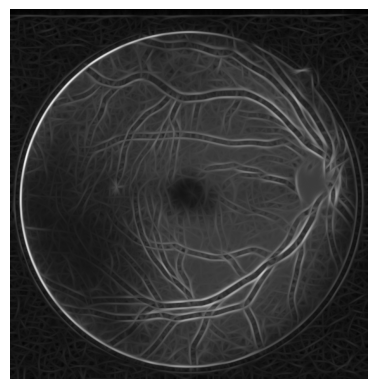

In [11]:
import matplotlib.pyplot as plt

index = 37

plt.imshow(imm_gauss[index], cmap='gray')
plt.axis('off')
plt.show()

In [12]:
mask_matrix = []

folders = [
    "/content/DRIVE/DRIVE/training/1st_manual",
    "/content/DRIVE/DRIVE/test/1st_manual"
]

for folder in folders:
    files = sorted(os.listdir(folder))

    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.gif')):

            path = os.path.join(folder, file)

            m = cv2.imread(path, 0)
            if m is None:
                continue

            , m = cv2.threshold(m, 127, 255, cv2.THRESH_BINARY)

            mask_matrix.append(m)

print(len(mask_matrix))

40


In [13]:
final_vessels = []

for i in range(len(imm_gauss)):
    vessel = imm_gauss[i]
    mask = mask_matrix[i]

    masked = cv2.bitwise_and(vessel, mask)
    final_vessels.append(masked)

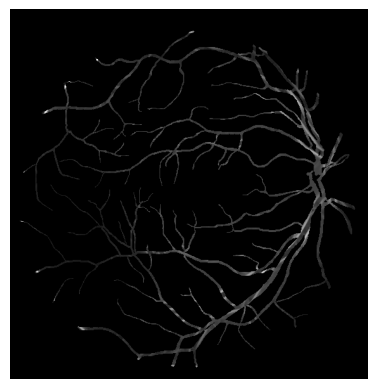

In [14]:
plt.imshow(final_vessels[37], cmap='gray')
plt.axis('off')
plt.show()

Processed: 40


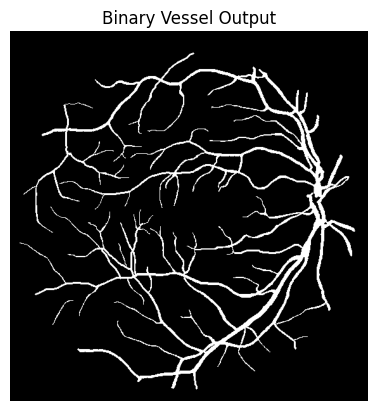

In [15]:
import cv2
import matplotlib.pyplot as plt

binary_vessels = []

for img in final_vessels:
    ret, th = cv2.threshold(img, 12, 255, cv2.THRESH_BINARY)
    binary_vessels.append(th)

print("Processed:", len(binary_vessels))

if len(binary_vessels) > 0:
    index = 37 if len(binary_vessels) > 19 else 0

    plt.imshow(binary_vessels[index], cmap='gray')
    plt.title("Binary Vessel Output")
    plt.axis('off')
    plt.show()
else:
    print("No output found")

In [16]:
clean_vessels = []

kernel = np.ones((3,3), np.uint8)

for img in binary_vessels:
    cleaned = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    clean_vessels.append(cleaned)

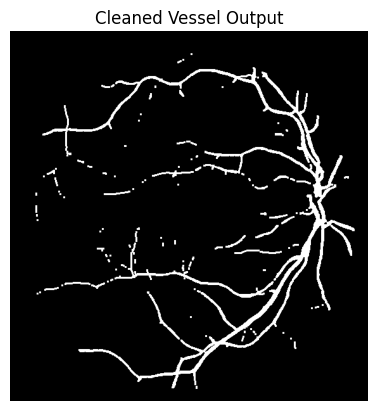

In [17]:
index = 37
plt.imshow(clean_vessels[index], cmap='gray')
plt.title("Cleaned Vessel Output")
plt.axis('off')
plt.show()

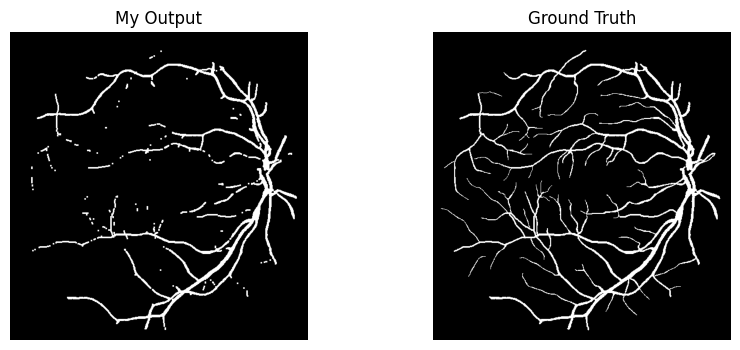

In [18]:
gt = mask_matrix[index]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(clean_vessels[index], cmap='gray')
plt.title("My Output")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

In [19]:
import numpy as np

pred = clean_vessels[index] // 255
gt = mask_matrix[index] // 255

TP = np.sum((pred == 1) & (gt == 1))
TN = np.sum((pred == 0) & (gt == 0))
FP = np.sum((pred == 1) & (gt == 0))
FN = np.sum((pred == 0) & (gt == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)

Accuracy: 0.9786580191538369


In [20]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP +1e-6)
recall = TP / (TP + FN +1e-6)
specificity = TN / (TN + FP + 1e-6)
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Specificity", specificity)
print("F1", f1)

Accuracy: 0.9786580191538369
Precision: 0.9999999999476494
Recall: 0.7306456548068143
Specificity 0.9999999999967085
F1 0.8443614446210862


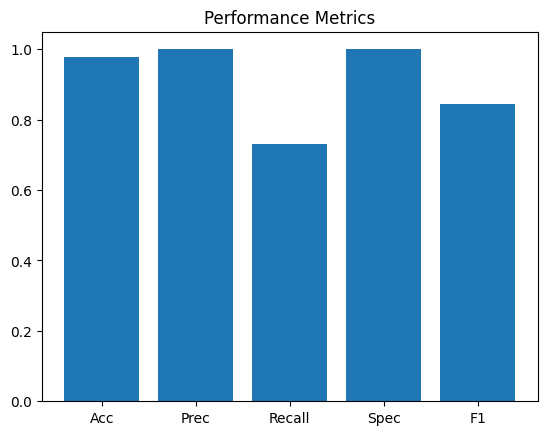

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

pred = clean_vessels[index]//255
gt = mask_matrix[index] // 255

TP = np.sum((pred == 1) & (gt == 1))
TN = np.sum((pred == 0) & (gt == 0))
FP = np.sum((pred == 1) & (gt == 0))
FN = np.sum((pred == 0) & (gt == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
specificity = TN / (TN + FP + 1e-6)
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

mse = np.mean((pred - gt) ** 2)
psnr = 20 * np.log10(255 / np.sqrt(mse)) if mse != 0 else 100

ssim_val = ssim(pred, gt)

metrics = ["Acc", "Prec", "Recall", "Spec", "F1"]
values = [accuracy, precision, recall, specificity, f1]

plt.bar(metrics, values)
plt.title("Performance Metrics")
plt.show()


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_metrics = []

for i in range(len(clean_vessels)):
    pred = clean_vessels[i] // 255
    gt = mask_matrix[i] // 255

    TP = np.sum((pred == 1) & (gt == 1))
    TN = np.sum((pred == 0) & (gt == 0))
    FP = np.sum((pred == 1) & (gt == 0))
    FN = np.sum((pred == 0) & (gt == 1))

    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

    all_metrics.append([accuracy, precision, recall, specificity, f1])

df = pd.DataFrame(all_metrics, columns=["Accuracy", "Precision", "Recall", "Specificity", "F1"])

print(df)

    Accuracy  Precision    Recall  Specificity        F1
0   0.980176        1.0  0.734731          1.0  0.847083
1   0.974336        1.0  0.715925          1.0  0.834447
2   0.990429        1.0  0.854624          1.0  0.921614
3   0.979337        1.0  0.821654          1.0  0.902096
4   0.981586        1.0  0.808140          1.0  0.893891
5   0.984331        1.0  0.812498          1.0  0.896550
6   0.975133        1.0  0.717779          1.0  0.835706
7   0.975664        1.0  0.750838          1.0  0.857689
8   0.978591        1.0  0.745451          1.0  0.854164
9   0.979158        1.0  0.734315          1.0  0.846806
10  0.984044        1.0  0.735401          1.0  0.847528
11  0.982513        1.0  0.786170          1.0  0.880285
12  0.979010        1.0  0.740463          1.0  0.850880
13  0.969893        1.0  0.692322          1.0  0.818191
14  0.974403        1.0  0.704809          1.0  0.826848
15  0.973663        1.0  0.757831          1.0  0.862234
16  0.977503        1.0  0.7426

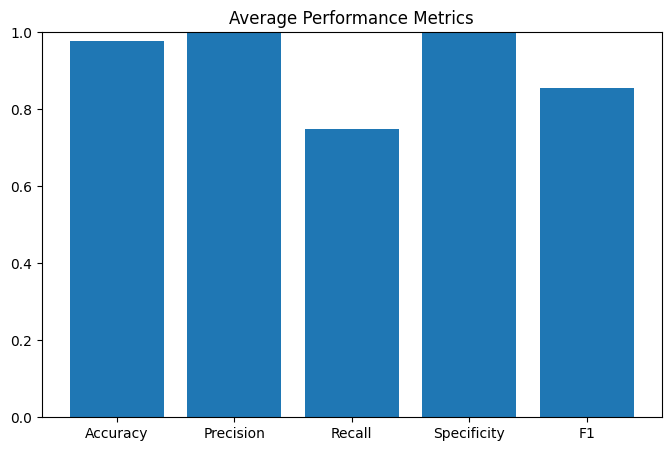

In [23]:
metrics = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

means = df[metrics].mean()

plt.figure(figsize=(8,5))
plt.bar(metrics, means)
plt.ylim(0,1)
plt.title("Average Performance Metrics")
plt.show()

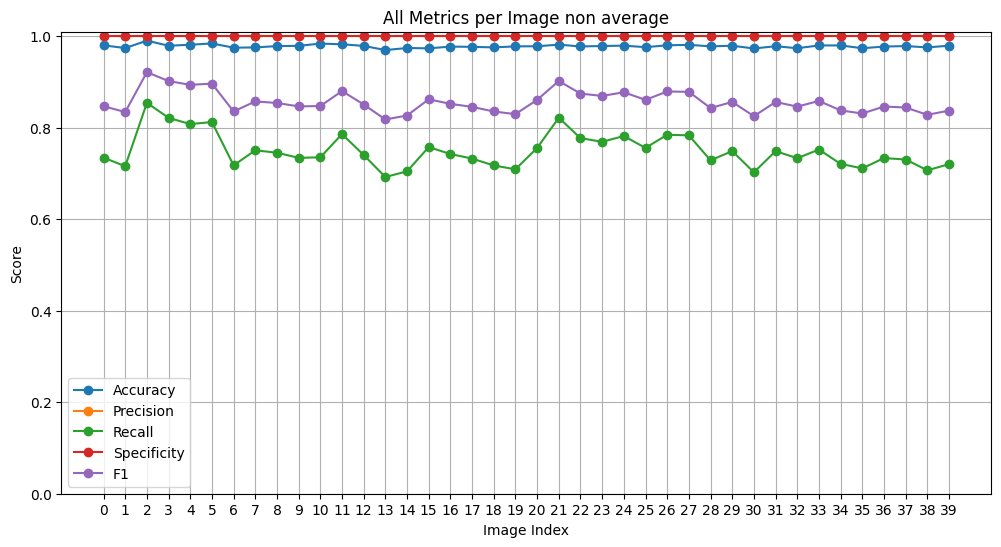

In [24]:
metrics = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

x = np.arange(len(df))  # 0,1,2,...N

plt.figure(figsize=(12,6))

for m in metrics:
    plt.plot(x, df[m], marker='o', label=m)

plt.xticks(x)
plt.ylim(0,1.01)
plt.xlabel("Image Index")
plt.ylabel("Score")
plt.title("All Metrics per Image non average")
plt.legend()
plt.grid()

plt.show()

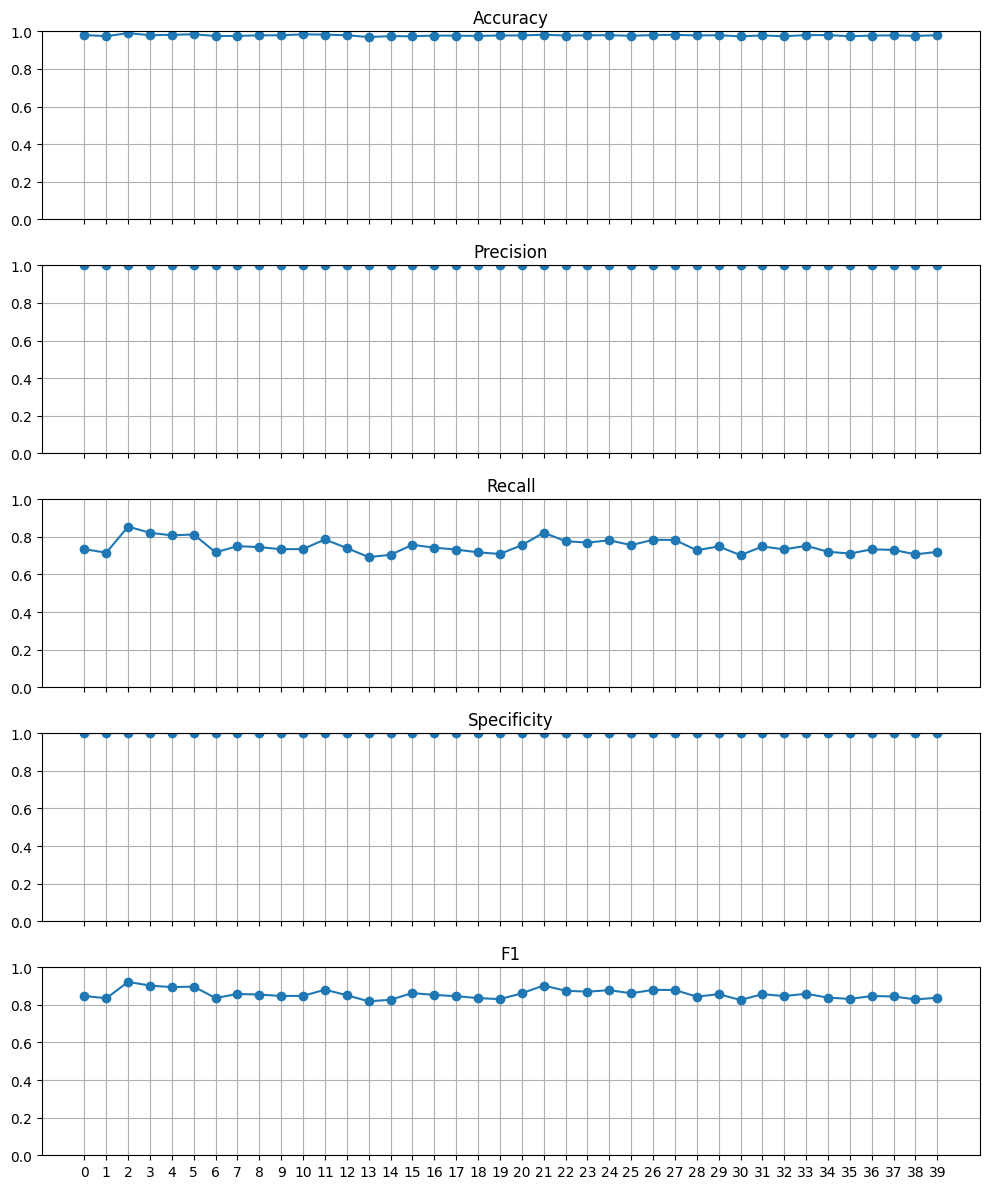

In [25]:
fig, axs = plt.subplots(5, 1, figsize=(10,12), sharex=True)

for i, m in enumerate(metrics):
    axs[i].plot(df[m], marker='o')
    axs[i].set_title(m)
    axs[i].set_ylim(0,1)
    axs[i].grid()

axs[-1].set_xticks(range(len(df)))

plt.tight_layout()
plt.show()

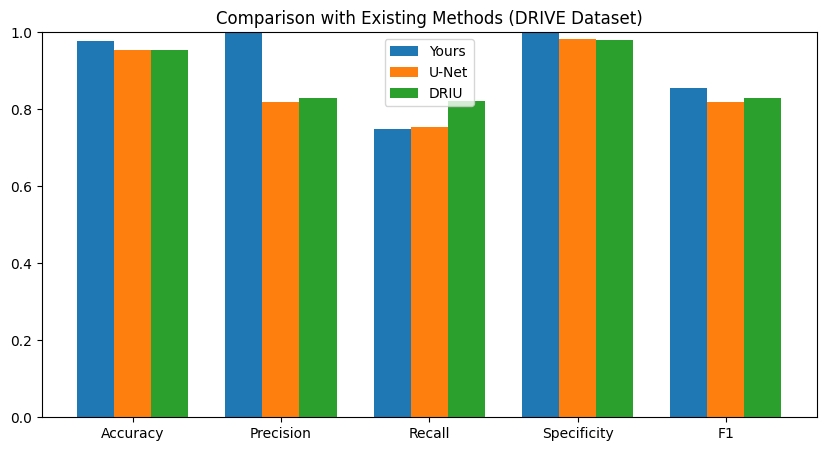

In [26]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy","Precision","Recall","Specificity","F1"]

your_scores = df[metrics].mean().values

unet = [0.9531, 0.82, 0.7537, 0.9820, 0.82]

driu = [0.9541, 0.83, 0.8220, 0.9810, 0.83]

methods = ["Yours", "U-Net", "DRIU"]
data = [your_scores, unet, driu]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,5))

for i in range(len(methods)):
    plt.bar(x + i*width, data[i], width, label=methods[i])

plt.xticks(x + width, metrics)
plt.ylim(0,1)
plt.title("Comparison with Existing Methods (DRIVE Dataset)")
plt.legend()

plt.show()

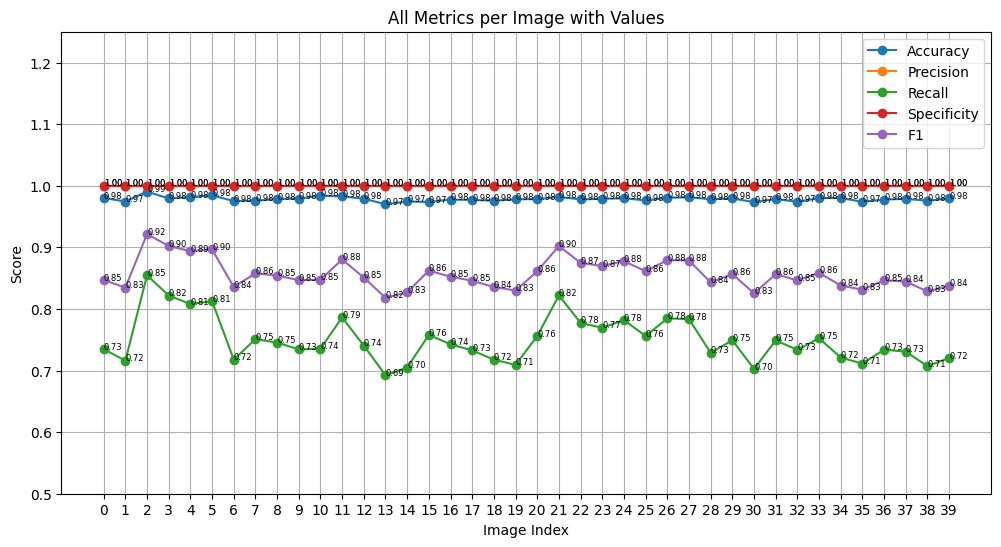

In [27]:
metrics = ["Accuracy","Precision","Recall","Specificity","F1"]

x = np.arange(len(df))

plt.figure(figsize=(12,6))

for m in metrics:
    y = df[m].values
    plt.plot(x, y, marker='o', label=m)

    for i in range(len(x)):
        plt.text(x[i], y[i], f"{y[i]:.2f}", fontsize=6)

plt.xticks(x)
plt.ylim(0.5,1.25)
plt.xlabel("Image Index")
plt.ylabel("Score")
plt.title("All Metrics per Image with Values")
plt.legend()
plt.grid()

plt.show()

In [28]:
import cv2
import numpy as np
exudate_maps = []

for img in imatrix:
  blur = cv2.GaussianBlur(img, (9,9), 0)
  diff = cv2.subtract(img, blur)
  _, exu = cv2.threshold(diff, 12, 255, cv2.THRESH_BINARY)

  kernal = np.ones((3,3), np.uint8)
  exu = cv2.morphologyEx(exu,cv2.MORPH_OPEN, kernal)
  exudate_maps.append(exu)
  print(len(exudate_maps))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


01_test.tif 01_manual1.gif
(584, 565) (584, 565)


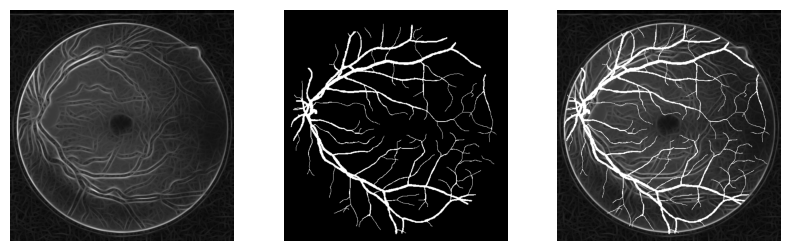

In [29]:
import os
import matplotlib.pyplot as plt

i = 0

image_folder = "/content/DRIVE/DRIVE/test/images"
mask_folder = "/content/DRIVE/DRIVE/test/1st_manual"

image_files = sorted(os.listdir(image_folder))
mask_files = sorted(os.listdir(mask_folder))

img = imm_gauss[i]
mask = mask_matrix[i]

print(image_files[i], mask_files[i])
print(img.shape, mask.shape)

overlay = img.copy()
overlay[mask > 0] = 255

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay, cmap='gray'); plt.axis('off')
plt.show()